In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

In [ ]:

!pip install kagglehub -q

import kagglehub
import os

path = kagglehub.dataset_download("adilshamim8/student-performance-and-learning-style")
print("Path to dataset files:", path)

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print("CSV files found:", csv_files)

df = pd.read_csv(os.path.join(path, csv_files[0]))
print(f"\n Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head())

Using Colab cache for faster access to the 'student-performance-and-learning-style' dataset.
Path to dataset files: /kaggle/input/student-performance-and-learning-style
CSV files found: ['student_performance.csv']

 Dataset loaded: 14003 rows × 16 columns


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


In [ ]:
df.drop_duplicates(inplace=True)

for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

grade_col = [c for c in df.columns if 'grade' in c.lower() or 'category' in c.lower()][0]
print("Target column:", grade_col)

num_cols = [c for c in df.select_dtypes(include='number').columns if c != grade_col]
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 3*IQR) & (df[col] <= Q3 + 3*IQR)]

le_dict = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

target_le = le_dict.get(grade_col)

y = df[grade_col]
X = df.drop(columns=[grade_col])

scaler = MinMaxScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
feature_names = list(X.columns)

print("X shape:", X.shape)
print("y classes:", sorted(y.unique()))

Target column: FinalGrade
X shape: (11435, 15)
y classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (9148, 15) | Test: (2287, 15)


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=6, random_state=42),
    'SVM'                : SVC(kernel='rbf', C=5.0, gamma='scale', random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42)
}

trained = {}
cv_scores = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    cv = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores[name] = cv.mean()
    print(f"{name} — CV Accuracy: {cv.mean():.4f} ± {cv.std():.4f} ")

Logistic Regression — CV Accuracy: 0.9792 ± 0.0036 
Decision Tree — CV Accuracy: 1.0000 ± 0.0000 
SVM — CV Accuracy: 0.9664 ± 0.0040 
Random Forest — CV Accuracy: 1.0000 ± 0.0000 


In [ ]:
results = {}
print(f"{'Model':<22} {'Train Acc':>10} {'Test Acc':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 75)

for name, model in trained.items():
    y_pred = model.predict(X_test)
    res = {
        'train_acc' : accuracy_score(y_train, model.predict(X_train)),
        'test_acc'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall'    : recall_score(y_test, y_pred, average='macro', zero_division=0),
        'f1'        : f1_score(y_test, y_pred, average='macro', zero_division=0),
        'cm'        : confusion_matrix(y_test, y_pred),
        'y_pred'    : y_pred
    }
    results[name] = res
    print(f"{name:<22} {res['train_acc']:>10.4f} {res['test_acc']:>10.4f} "
          f"{res['precision']:>10.4f} {res['recall']:>10.4f} {res['f1']:>10.4f}")

Model                   Train Acc   Test Acc  Precision     Recall         F1
---------------------------------------------------------------------------
Logistic Regression        0.9835     0.9812     0.9824     0.9801     0.9810
Decision Tree              1.0000     1.0000     1.0000     1.0000     1.0000
SVM                        0.9939     0.9668     0.9664     0.9667     0.9666
Random Forest              1.0000     1.0000     1.0000     1.0000     1.0000


In [ ]:
results = {}
print(f"{'Model':<22} {'Train Acc':>10} {'Test Acc':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 75)

for name, model in trained.items():
    y_pred = model.predict(X_test)
    res = {
        'train_acc' : accuracy_score(y_train, model.predict(X_train)),
        'test_acc'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall'    : recall_score(y_test, y_pred, average='macro', zero_division=0),
        'f1'        : f1_score(y_test, y_pred, average='macro', zero_division=0),
        'cm'        : confusion_matrix(y_test, y_pred),
        'y_pred'    : y_pred
    }
    results[name] = res
    print(f"{name:<22} {res['train_acc']:>10.4f} {res['test_acc']:>10.4f} "
          f"{res['precision']:>10.4f} {res['recall']:>10.4f} {res['f1']:>10.4f}")

Model                   Train Acc   Test Acc  Precision     Recall         F1
---------------------------------------------------------------------------
Logistic Regression        0.9835     0.9812     0.9824     0.9801     0.9810
Decision Tree              1.0000     1.0000     1.0000     1.0000     1.0000
SVM                        0.9939     0.9668     0.9664     0.9667     0.9666
Random Forest              1.0000     1.0000     1.0000     1.0000     1.0000


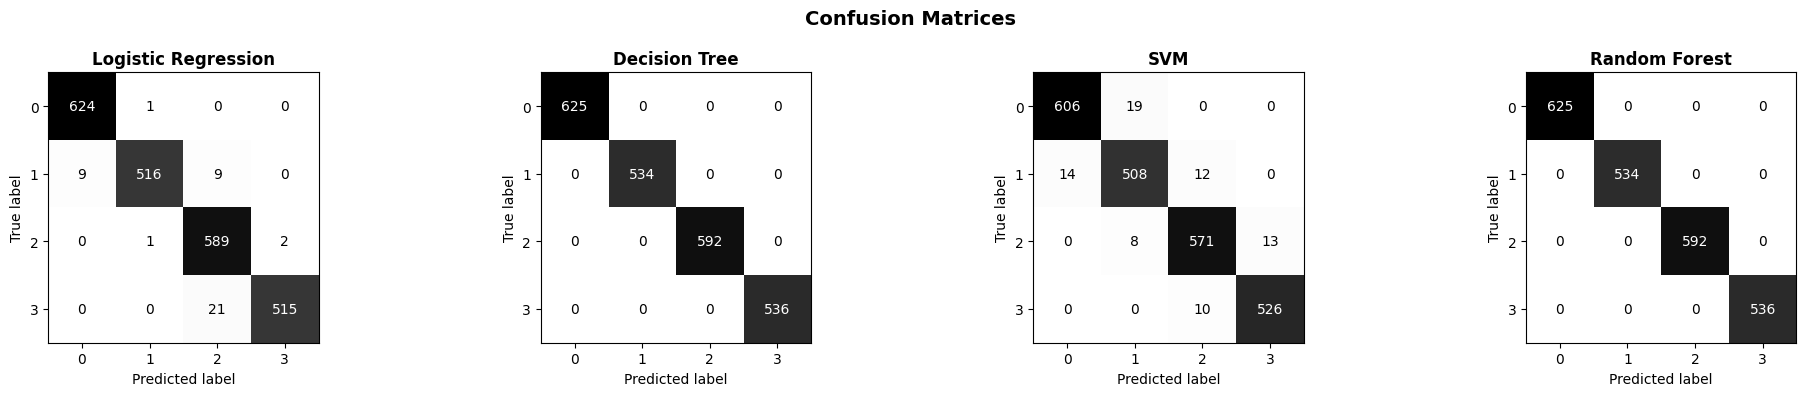

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
class_names = target_le.classes_ if target_le else None

for ax, (name, res) in zip(axes, results.items()):
    ConfusionMatrixDisplay(res['cm'], display_labels=class_names).plot(
        ax=ax, colorbar=False, cmap='Greys')
    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

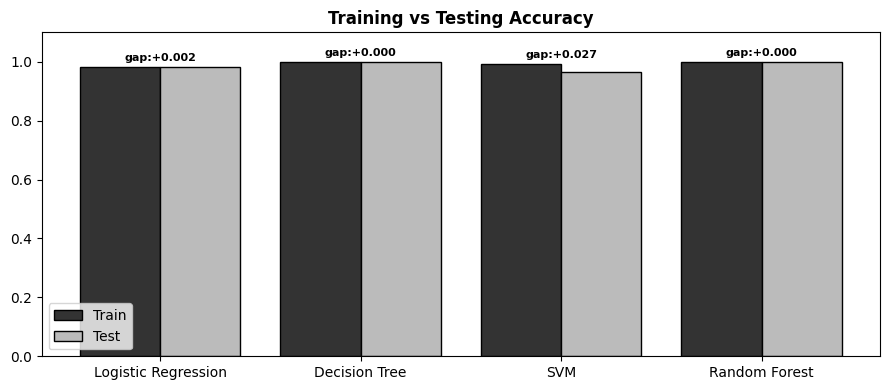

In [ ]:
names      = list(results.keys())
train_accs = [results[n]['train_acc'] for n in names]
test_accs  = [results[n]['test_acc']  for n in names]
x = np.arange(len(names))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - 0.2, train_accs, 0.4, label='Train', color='#333333', edgecolor='black')
ax.bar(x + 0.2, test_accs,  0.4, label='Test',  color='#bbbbbb', edgecolor='black')

for i, (tr, te) in enumerate(zip(train_accs, test_accs)):
    ax.text(i, max(tr, te) + 0.02, f'gap:{tr-te:+.3f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0, 1.1)
ax.set_title('Training vs Testing Accuracy', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('train_vs_test.png', dpi=150)
plt.show()

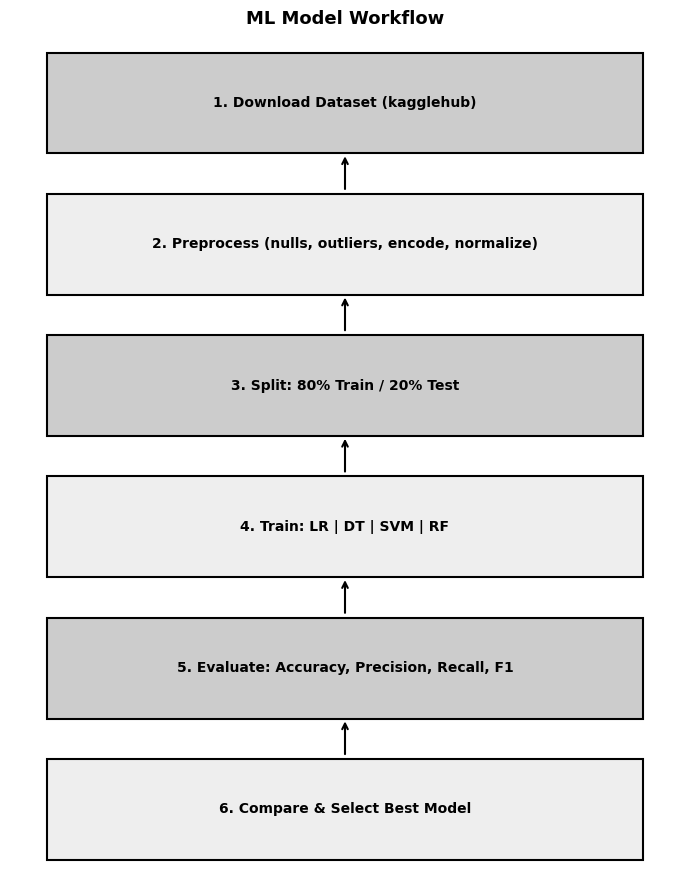

In [ ]:
steps = [
    '1. Download Dataset (kagglehub)',
    '2. Preprocess (nulls, outliers, encode, normalize)',
    '3. Split: 80% Train / 20% Test',
    '4. Train: LR | DT | SVM | RF',
    '5. Evaluate: Accuracy, Precision, Recall, F1',
    '6. Compare & Select Best Model'
]

fig, ax = plt.subplots(figsize=(7, 9))
ax.axis('off')
for i, step in enumerate(reversed(steps)):
    y0 = i * 1.4 + 0.2
    shade = '#eeeeee' if i % 2 == 0 else '#cccccc'
    ax.add_patch(plt.Rectangle((0.5, y0), 8, 1, linewidth=1.5,
                                edgecolor='black', facecolor=shade))
    ax.text(4.5, y0 + 0.5, step, ha='center', va='center',
            fontsize=10, fontweight='bold')
    if i < len(steps) - 1:
        ax.annotate('', xy=(4.5, y0 + 1.4), xytext=(4.5, y0 + 1.02),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

ax.set_xlim(0, 9)
ax.set_ylim(0, len(steps)*1.4)
ax.set_title('ML Model Workflow', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('workflow_diagram.png', dpi=150)
plt.show()

In [ ]:
best = max(results, key=lambda n: results[n]['f1'])
print("=" * 45)
print("         FINAL SUMMARY")
print("=" * 45)
for name, res in results.items():
    acc_status = " if res['test_acc'] >= 0.85 else "
    f1_status  = " if res['f1'] >= 0.82 else "
    print(f"{name:<22} | Acc:{res['test_acc']:.4f}{acc_status} | F1:{res['f1']:.4f}{f1_status}")
print("=" * 45)
print(f" Best Model: {best}  (F1 = {results[best]['f1']:.4f})")

         FINAL SUMMARY
Logistic Regression    | Acc:0.9812 if res['test_acc'] >= 0.85 else  | F1:0.9810 if res['f1'] >= 0.82 else 
Decision Tree          | Acc:1.0000 if res['test_acc'] >= 0.85 else  | F1:1.0000 if res['f1'] >= 0.82 else 
SVM                    | Acc:0.9668 if res['test_acc'] >= 0.85 else  | F1:0.9666 if res['f1'] >= 0.82 else 
Random Forest          | Acc:1.0000 if res['test_acc'] >= 0.85 else  | F1:1.0000 if res['f1'] >= 0.82 else 
 Best Model: Decision Tree  (F1 = 1.0000)
